# **When AI Learns to Think Like Humans**
You might think that AI just needs data to answer any question. In reality, **whether it's a small or large model**, it's not that simple. AIs that **only process blindly, without sequential reasoning**, are at risk of giving **wrong or awkward answers to complex problems**.

Small AI, with limited data or few parameters, lacks intuition and planning ability. Large AI, despite having enormous knowledge, can still **make similar mistakes** if it only relies on data without 'thinking' like humans.

That is why reasoning methods like **Chain-of-Thought**, **Few-Shot**, and **Self-Consistency** become important. They help AI **simulate human thinking**, generate logical solving steps, check results, reduce errors, and improve answer quality.

Therefore, we will try some methods to force the model to simulate human thinking and compare the effectiveness.

## About the Dataset

In this notebook, we use **GSM8K** to evaluate AI reasoning ability.

**GSM8K** consists of ~8,500 grade school math problems. Key features:
- **Multi-step problems**: sequential reasoning required, not just simple calculation
- **Variety of types**: arithmetic, logic, "theory + practice" problems
- **Reasoning evaluation**: correct answers require building explanatory steps first — ideal for testing CoT, Self-Consistency, and MCTS

In [66]:
!pip install datasets litellm matplotlib -q

In [67]:
from datasets import load_dataset
import pandas as pd, re, os, math, time, json, random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

dataset = load_dataset('gsm8k', 'main')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})


In [68]:
def gsm8k_to_dataframe(num_examples=20):
    data = []
    for i in range(num_examples):
        q = dataset['test'][i]['question']
        a = dataset['test'][i]['answer']
        m = re.findall(r'#### (\d+)', a)
        data.append({'question': q, 'true_answer': m[0] if m else a.strip()})
    return pd.DataFrame(data)

get some sample

In [69]:
df_test = gsm8k_to_dataframe(num_examples=10).sample(frac=1, random_state=42).reset_index(drop=True) #edit the number of sample you want to take here
print(df_test[['question','true_answer']])

                                            question true_answer
0  John drives for 3 hours at a speed of 60 mph a...          45
1  A robe takes 2 bolts of blue fiber and half th...           3
2  Kylar went to the store to buy glasses for his...          64
3  Janet’s ducks lay 16 eggs per day. She eats th...          18
4  Carla is downloading a 200 GB file. Normally s...         160
5  Josh decides to try flipping a house.  He buys...       70000
6  Eliza's rate per hour for the first 40 hours s...         460
7  Every day, Wendi feeds each of her chickens th...          20
8  James decides to run 3 sprints 3 times a week....         540
9  Toulouse has twice as many sheep as Charleston...         260


## Initialize LLM

> **Security note:** Set your API key via environment variable, not hardcoded in source.

In [ ]:
from litellm import completion

api_key = os.environ.get('DEEPSEEK_API_KEY', 'YOUR_API_KEY')

def call_llm(messages, model='deepseek/deepseek-chat', max_tokens=1000):
    res = completion(model=model, messages=messages,
                     max_tokens=max_tokens, api_key=api_key)
    content      = res['choices'][0]['message']['content']
    total_tokens = res.usage.total_tokens
    return content, total_tokens

## Shared Utilities
Used by all methods below.

In [71]:
def extract_number(text):
    """Extract final numeric answer from LLM output."""
    m = re.search(r'Final\s+Answer\s*[:\-]\s*([-+]?\d+(?:[.,]\d+)?)', text, re.I)
    if m: return m.group(1).replace(',', '')
    nums = re.findall(r'[-+]?\d+(?:\.\d+)?', text)
    return nums[-1] if nums else None

COT_SYSTEM = (
    'Solve the problem by thinking step by step naturally. '
    'When done, write your final answer on a new line as:\n'
    'Final Answer: <number only>'
)

def build_prompt_cot(question):
    return [
        {'role': 'system', 'content': COT_SYSTEM},
        {'role': 'user',   'content': f'Question: {question}\nSolution:'},
    ]

def sep(char='─', n=60): print(char * n)

## 1. Chain-of-Thought (CoT)

**Chain-of-Thought (CoT)** helps AI solve problems by **thinking step by step** instead of answering immediately.

**How it works:**
- The model writes out its full reasoning process naturally
- Concludes with `Final Answer: <number>`

First — **without** CoT (direct answer, no reasoning):

In [72]:
def build_prompt_direct(question):
    return [
        {'role': 'system', 'content': 'Answer directly. End with:\nFinal Answer: <number only>'},
        {'role': 'user',   'content': f'Question: {question}\nAnswer:'},
    ]

print('=' * 60)
print('DIRECT (no reasoning)')
print('=' * 60)
res_direct = []
for i, row in df_test.iterrows():
    text, _ = call_llm(build_prompt_direct(row['question']), max_tokens=80)
    pred     = extract_number(text)
    correct  = str(pred).strip() == str(row['true_answer']).strip()
    res_direct.append(int(correct))
    mark = '✓' if correct else '✗'
    print(f'[{i+1:02d}] {mark}  Pred={str(pred):<8} GT={row["true_answer"]}')

acc_direct = sum(res_direct) / len(res_direct)
print(f'\n{"="*60}')
print(f'Direct Accuracy: {sum(res_direct)}/{len(res_direct)} = {acc_direct:.1%}')

DIRECT (no reasoning)
[01] ✗  Pred=4        GT=45
[02] ✓  Pred=3        GT=3
[03] ✗  Pred=5        GT=64
[04] ✗  Pred=2        GT=18
[05] ✗  Pred=0.4      GT=160
[06] ✗  Pred=150      GT=70000
[07] ✗  Pred=12       GT=460
[08] ✓  Pred=20       GT=20
[09] ✓  Pred=540      GT=540
[10] ✓  Pred=260      GT=260

Direct Accuracy: 4/10 = 40.0%


Now — **with** CoT (step-by-step reasoning):

In [73]:
def cot(question, total_token_budget=1000, verbose=True):
    t0 = time.perf_counter()
    messages = build_prompt_cot(question)
    text, tokens = call_llm(messages, max_tokens=total_token_budget)
    answer  = extract_number(text)
    latency = round(time.perf_counter() - t0, 2)
    if verbose:
        print('  ---Reasoning-----')
        for line in text.strip().split('\n'):
            print(f'  │ {line}')
        print('  --------')
    return {'method': 'CoT', 'final': answer, 'text': text,
            'tokens_used': tokens, 'latency': latency}

print('=' * 60)
print('CoT  (Chain-of-Thought)')
print('=' * 60)
results_cot = []
for i, row in df_test.iterrows():
    result  = cot(row['question'], total_token_budget=1000, verbose=True)
    correct = str(result['final']).strip() == str(row['true_answer']).strip()
    results_cot.append({**result, 'correct': int(correct),
                        'question': row['question'], 'true_answer': row['true_answer']})
    mark = '✓' if correct else '✗'
    print(f'[{i+1:02d}] {mark}  Pred={str(result["final"]):<8} GT={row["true_answer"]:<8}'
          f' | {result["tokens_used"]} tok | {result["latency"]}s')
    print()

acc_cot = sum(r['correct'] for r in results_cot) / len(results_cot)
print(f'{"="*60}')
print(f'CoT Accuracy: {sum(r["correct"] for r in results_cot)}/{len(results_cot)} = {acc_cot:.1%}')

CoT  (Chain-of-Thought)
  ---Reasoning-----
  │ Let’s break this down step by step.  
  │ 
  │ ---
  │ 
  │ **Step 1: John’s initial trip away from home**  
  │ He drives for 3 hours at 60 mph.  
  │ Distance from home after this:  
  │ \[
  │ 3 \times 60 = 180 \text{ miles}
  │ \]  
  │ 
  │ ---
  │ 
  │ **Step 2: Turning back toward home**  
  │ He wants to get home in 4 hours total for the return trip.  
  │ 
  │ The return trip is split into:  
  │ 1. First 2 hours: standstill traffic → speed = 0 mph.  
  │ Distance covered in these 2 hours:  
  │ \[
  │ 2 \times 0 = 0 \text{ miles}
  │ \]  
  │ 
  │ 2. Next 0.5 hours: speed = 30 mph.  
  │ Distance covered:  
  │ \[
  │ 0.5 \times 30 = 15 \text{ miles}
  │ \]  
  │ 
  │ 3. Remaining time of the 4-hour return trip:  
  │ Total return trip time = 4 hours.  
  │ Time used so far = \( 2 + 0.5 = 2.5 \) hours.  
  │ Remaining time = \( 4 - 2.5 = 1.5 \) hours.  
  │ 
  │ Speed in this last segment = 80 mph.  
  │ Distance covered:  
  │ 

### Limitations of Chain-of-Thought
- **One wrong step → entire chain fails** — errors cascade forward
- **"Plausible but wrong"** — confident-sounding but incorrect reasoning
- **Prompt-dependent** — poor framing leads AI off-track
- **Single path** — commits to first direction with no backtracking

## 2. Self-Consistency

**Self-Consistency** runs CoT **multiple times** and takes **majority vote** as the final answer.

- Same `total_token_budget`, split equally across `n_votes` calls
- More robust — random errors tend to cancel out

In [74]:
def cot_self_consistency(question, n_votes=3, total_token_budget=1000, verbose=True):
    budget_per_call = total_token_budget // n_votes
    answers, tokens_total, latencies = [], 0, []

    for i in range(n_votes):
        t0 = time.perf_counter()
        text, tokens = call_llm(build_prompt_cot(question), max_tokens=budget_per_call)
        answer = extract_number(text)
        tokens_total += tokens
        latencies.append(time.perf_counter() - t0)
        if answer: answers.append(answer)
        if verbose:
            print(f'  Vote {i+1}: → {answer}')

    if not answers:
        return {'method': 'Self-Consistency', 'final': None, 'confidence': 0.0,
                'tokens_used': tokens_total, 'latency': round(sum(latencies), 2)}

    dist = Counter(answers)
    best, count = dist.most_common(1)[0]
    return {'method': 'Self-Consistency', 'final': best,
            'confidence':   round(count / len(answers), 3),
            'distribution': dict(dist),
            'tokens_used':  tokens_total,
            'latency':      round(sum(latencies), 2)}


In [75]:

print('=' * 60)
print('Self-Consistency  (3 votes)')
print('=' * 60)
results_sc = []
for i, row in df_test.iterrows():
    result  = cot_self_consistency(row['question'], n_votes=3,
                                    total_token_budget=1000, verbose=True)
    correct = str(result['final']).strip() == str(row['true_answer']).strip()
    results_sc.append({**result, 'correct': int(correct),
                       'question': row['question'], 'true_answer': row['true_answer']})
    mark = '✓' if correct else '✗'
    conf = result.get('confidence', 0)
    dist_str = str(result.get('distribution', {}))
    print(f'[{i+1:02d}] {mark}  Final={str(result["final"]):<8} GT={row["true_answer"]:<8}'
          f' conf={conf:.0%}  votes={dist_str}')
    print()

acc_sc = sum(r['correct'] for r in results_sc) / len(results_sc)
print(f'{"="*60}')
print(f'Self-Consistency Accuracy: {sum(r["correct"] for r in results_sc)}/{len(results_sc)} = {acc_sc:.1%}')

Self-Consistency  (3 votes)
  Vote 1: → 45
  Vote 2: → 3
  Vote 3: → 80
[01] ✓  Final=45       GT=45       conf=33%  votes={'45': 1, '3': 1, '80': 1}

  Vote 1: → 3
  Vote 2: → 3
  Vote 3: → 3
[02] ✓  Final=3        GT=3        conf=100%  votes={'3': 3}

  Vote 1: → 64
  Vote 2: → 64
  Vote 3: → 64
[03] ✓  Final=64       GT=64       conf=100%  votes={'64': 3}

  Vote 1: → 18
  Vote 2: → 18
  Vote 3: → 18
[04] ✓  Final=18       GT=18       conf=100%  votes={'18': 3}

  Vote 1: → 160
  Vote 2: → 160
  Vote 3: → 160
[05] ✓  Final=160      GT=160      conf=100%  votes={'160': 3}

  Vote 1: → 25000
  Vote 2: → 150
  Vote 3: → 25000
[06] ✗  Final=25000    GT=70000    conf=67%  votes={'25000': 2, '150': 1}

  Vote 1: → 460
  Vote 2: → 460
  Vote 3: → 460
[07] ✓  Final=460      GT=460      conf=100%  votes={'460': 3}

  Vote 1: → 20
  Vote 2: → 20
  Vote 3: → 20
[08] ✓  Final=20       GT=20       conf=100%  votes={'20': 3}

  Vote 1: → 540
  Vote 2: → 540
  Vote 3: → 540
[09] ✓  Final=540     

### Limitations
- **Majority wrong → still wrong** — shared systematic errors aren't caught
- **No explanation** — hard to understand why majority chose an answer
- **Budget split** — each vote gets fewer tokens than single CoT

## 3. Best-of-N

**Best-of-N** generates N independent answers, scores each with the model, picks the highest-scoring one.

- 80% of budget → generation, 20% → scoring
- Better when answers are all different (no clear majority)

In [76]:
def build_prompt_verify(question, answer, reasoning):
    return [
        {'role': 'system', 'content': (
            'You are an expert logical verifier. You DO NOT know the true answer.\n'
            'Your task is to score the solution from 0.0 to 1.0 based ONLY on logical consistency and arithmetic accuracy.\n'
            'Deduct points heavily if there are logical leaps, contradictions, missing steps, or mathematical calculation errors.\n'
            'If the steps perfectly justify the final answer, give a high score.\n'
            'Return ONLY a float number.'
        )},
        {'role': 'user', 'content':
            f'Question: {question}\n\nReasoning:\n{reasoning}\n\nFinal Answer: {answer}'},
    ]
def cot_best_of_n(question, n=3, total_token_budget=1000, verbose=False):
    gen_budget   = int(total_token_budget * 0.8) // n
    score_budget = max(20, int(total_token_budget * 0.2) // n)
    candidates, tokens_total, latencies = [], 0, []

    for i in range(n):
        t0 = time.perf_counter()
        text, tok_gen = call_llm(build_prompt_cot(question), max_tokens=gen_budget)
        answer = extract_number(text)
        tokens_total += tok_gen
        if not answer:
            latencies.append(time.perf_counter() - t0)
            continue
        score_text, tok_score = call_llm(
            build_prompt_verify(question, answer, text), max_tokens=score_budget)
        tokens_total += tok_score
        try:
            score = float(re.search(r'\d+\.?\d*', score_text).group())
            score = min(max(score, 0.0), 1.0)
        except:
            score = 0.0
        candidates.append({'answer': answer, 'score': score, 'text': text})
        latencies.append(time.perf_counter() - t0)
        if verbose:
            print(f'    Candidate {i+1}: ans={str(answer):<8} score={score:.2f}')

    if not candidates:
        return {'method': 'Best-of-N', 'final': None, 'best_score': 0.0,
                'tokens_used': tokens_total, 'latency': round(sum(latencies), 2)}

    best = max(candidates, key=lambda x: x['score'])
    return {'method': 'Best-of-N', 'final': best['answer'],
            'best_score': best['score'], 'all_scores': [c['score'] for c in candidates],
            'tokens_used': tokens_total, 'latency': round(sum(latencies), 2)}


In [77]:

print('=' * 60)
print('Best-of-N  (n=3)')
print('=' * 60)
results_bon = []
for i, row in df_test.iterrows():
    result  = cot_best_of_n(row['question'], n=3, total_token_budget=1000, verbose=True)
    correct = str(result['final']).strip() == str(row['true_answer']).strip()
    results_bon.append({**result, 'correct': int(correct),
                        'question': row['question'], 'true_answer': row['true_answer']})
    mark = '✓' if correct else '✗'
    print(f'[{i+1:02d}] {mark}  Final={str(result["final"]):<8} GT={row["true_answer"]:<8}'
          f' best_score={result.get("best_score",0):.2f}')
    print()

acc_bon = sum(r['correct'] for r in results_bon) / len(results_bon)
print(f'{"="*60}')
print(f'Best-of-N Accuracy: {sum(r["correct"] for r in results_bon)}/{len(results_bon)} = {acc_bon:.1%}')

Best-of-N  (n=3)
    Candidate 1: ans=1.5      score=0.00
    Candidate 2: ans=0        score=0.00
    Candidate 3: ans=2.5      score=0.00
[01] ✗  Final=1.5      GT=45       best_score=0.00

    Candidate 1: ans=3        score=0.90
    Candidate 2: ans=3        score=0.90
    Candidate 3: ans=3        score=1.00
[02] ✓  Final=3        GT=3        best_score=1.00

    Candidate 1: ans=64       score=1.00
    Candidate 2: ans=64       score=0.00
    Candidate 3: ans=16       score=0.00
[03] ✓  Final=64       GT=64       best_score=1.00

    Candidate 1: ans=18       score=0.90
    Candidate 2: ans=18       score=0.90
    Candidate 3: ans=18       score=0.90
[04] ✓  Final=18       GT=18       best_score=0.90

    Candidate 1: ans=20       score=0.00
    Candidate 2: ans=60       score=0.20
    Candidate 3: ans=20       score=0.00
[05] ✗  Final=60       GT=160      best_score=0.20

    Candidate 1: ans=25       score=0.50
    Candidate 2: ans=150      score=0.00
    Candidate 3: ans=25000

### Limitations
- **Self-assessment bias** — LLM tends to inflate scores for confident-sounding (but wrong) answers
- **Higher cost** — generation + scoring overhead per candidate
- **"Confidently wrong"** — no guarantee high score = correct answer

## Problems with the Above Methods

All three methods share a fundamental limitation:

> They are **independent trials** — each run starts fresh with no memory of what failed before. They cannot **backtrack** or **reuse promising partial reasoning**.

- **CoT**: linear, one shot
- **Self-Consistency**: independent — doesn't reuse good partial reasoning
- **Best-of-N**: picks best independent attempt — no incremental refinement

## MCTS (Monte Carlo Tree Search): Strategic Reasoning Exploration

You may have heard about AlphaGo defeating the world's top Go players. One of its core techniques is **Monte Carlo Tree Search (MCTS)**.

AlphaGo didn't just memorize moves — it **proactively explored and evaluated different possibilities before deciding**.

Applied to LLMs, MCTS:
- **Builds a reasoning tree** — partial solutions become branches to explore
- **Tries different paths** — multiple directions tested from each node
- **Evaluates each step** — scores guide which branches deserve more expansion
- **Reuses good partial reasoning** — promising starts are extended, bad starts abandoned

### UCB1 — The Heart of MCTS

UCB1 decides which node to visit next, balancing **exploit** (high value) vs **explore** (less visited):

$$UCB1(node) = \frac{Q(node)}{N(node)} + c \cdot \sqrt{\frac{\ln N(parent)}{N(node)}}$$

- $Q/N$: average reward → **exploit**
- Square root term: exploration bonus, decreases as node is visited more
- $c = 1.4$ (tune 0.5–2.0 for language tasks)

### 4 Repeating Steps

| Step | Action | LLM Role |
|---|---|---|
| **Selection** | Follow UCB1 to best leaf | — |
| **Expansion** | Generate k next reasoning steps | Policy: generate candidates |
| **Rollout** | Complete solution from leaf | Generate full answer |
| **Backprop** | Update scores up the tree | — |

| MCTS concept | LLM equivalent |
|---|---|
| State | Current prompt + reasoning so far |
| Action | Next reasoning step (LLM-generated) |
| Simulation | Full solution completion |
| Reward | Evaluator score (0-1) |

In [78]:
class Node:
    def __init__(self, state, parent=None, step_text='[root]'):
        self.state      = state
        self.step_text  = step_text
        self.parent     = parent
        self.children   = []
        self.visits     = 0
        self.value      = 0.0
        self.rollout_scores = []

    def is_leaf(self):
        return len(self.children) == 0

    def avg_value(self):
        return self.value / self.visits if self.visits else 0.0

    def ucb_score(self, c=1.4):
        if self.visits == 0:
            return float('inf')
        if self.parent is None or self.parent.visits == 0:
            return self.avg_value()
        return self.avg_value() + c * math.sqrt(
            math.log(self.parent.visits) / self.visits
        )

    def __repr__(self):
        return (f"Node(visits={self.visits}, avg={self.avg_value():.2f}, "
                f"step='{self.step_text[:40]}...')")

In [79]:
def select(node):
    """Traverse tree following UCB1 until a leaf is reached. Returns (leaf, path)."""
    path = [node]
    while not node.is_leaf():
        node = max(node.children, key=lambda n: n.ucb_score())
        path.append(node)
    return node, path

In [80]:
def expand(node, question, k=2):
    """LLM generates k distinct next reasoning steps (30-60 words each)."""
    children = []
    generated_steps = []  # track step already create

    for i in range(k):
        #pass all step to avoid duplictae
        existing = "\n".join(f"- {s}" for s in generated_steps)
        avoid_hint = f"\n\nSteps already taken by siblings (choose a DIFFERENT approach):\n{existing}" if existing else ""

        messages = [
            {'role': 'system', 'content': (
                'You are solving a math problem step by step.\n'
                'Generate ONLY the NEXT single reasoning step (1-2 sentences, ~30-60 words).\n'
                'Be concrete: state the specific calculation or logical deduction.\n'
                'Do NOT write a full solution. Do NOT repeat earlier steps.\n'
                'Your step must explore a DISTINCT approach from any siblings listed.'
            )},
            {'role': 'user', 'content': (
                f'Question: {question}\n\n'
                f'Reasoning so far:\n{node.state}'
                f'{avoid_hint}\n\n'
                'Next single step:'
            )},
        ]
        step, _ = call_llm(messages, max_tokens=80)
        step = step.strip()

        # Deduplicate: pass
        if any(similar(step, s) for s in generated_steps):
            continue

        generated_steps.append(step)
        new_state = node.state + '\nStep: ' + step
        child = Node(new_state, parent=node, step_text=step)
        node.children.append(child)
        children.append(child)

    return children


def similar(a, b, threshold=0.7):
    """(Jaccard on words)"""
    a_words = set(a.lower().split())
    b_words = set(b.lower().split())
    if not a_words or not b_words:
        return False
    return len(a_words & b_words) / len(a_words | b_words) > threshold

In [81]:
def rollout(node, question):
    """Complete solution from this node's partial reasoning."""
    messages = [
        {'role': 'system', 'content': COT_SYSTEM},
        {'role': 'user', 'content': (
            f'Question: {question}\n\n'
            f'Reasoning so far:\n{node.state}\n\n'
            'Continue reasoning and give the final answer:'
        )},
    ]
    result, tokens = call_llm(messages, max_tokens=400)
    return result, tokens

In [82]:
def evaluate(output, question):
    """
    Score a completed reasoning+answer (0.0-1.0)
    """
    extracted = extract_number(output)
    if extracted is None:
        return 0.05  # no answer found

    messages = [
        {'role': 'system', 'content': (
            'You are an expert logical verifier. You DO NOT know the final answer to the problem.\n'
            'First list any errors you find (logical gaps, wrong arithmetic). '
            'If you find NO errors, explain why each step is correct. '
            'Then give your score. Scores above 0.8 require zero errors found.'
            'Evaluate the provided solution based strictly on internal logic and mathematical rules using this rubric:\n'
            '  0.9-1.0: Flawless logic. Every step follows clearly from the previous one, and all arithmetic is correct.\n'
            '  0.6-0.8: Mostly logical, but contains minor leaps or relies on unstated assumptions. Math calculations appear correct.\n'
            '  0.3-0.5: Noticeable logical gaps or minor arithmetic errors that skew the final result.\n'
            '  0.0-0.2: Fundamentally flawed reasoning, contradictory statements, or obvious calculation errors.\n'
            'CRITICAL: Step through the logic carefully before scoring. Do not guess the answer, just verify the process.\n'
            'Return ONLY valid JSON: {"score": <0.0-1.0>, "reason": "<one sentence explanation>"}'
        )},
        {'role': 'user', 'content': (
            f'Question: {question}\n\n'
            f'Solution to verify:\n{output}\n\n'
            'Verification Grade:'
        )},
    ]
    response, _ = call_llm(messages, max_tokens=80)
    try:
        cleaned = response.strip()
        if '```' in cleaned:
            cleaned = cleaned.split('\n', 1)[1].rsplit('```', 1)[0]
        data  = json.loads(cleaned)
        score = float(data['score'])
        reason = data.get('reason', '')
        return min(max(score, 0.0), 1.0), reason
    except:
        try:
            score = float(re.search(r'\d+\.?\d*', response).group())
            return min(max(score / (10 if score > 1 else 1), 0.0), 1.0), ''
        except:
            return 0.1, ''

In [83]:
def backpropagate(node, reward):
    while node:
        node.visits += 1
        node.value  += reward
        node = node.parent

In [84]:
def mcts(problem, question, iterations=10, k=2, max_depth=5, verbose=True):
    """
    MCTS for LLM reasoning.
    """
    t0 = time.perf_counter()
    root = Node(problem, step_text='[root]')
    tokens_total = 0

    if verbose:
        print(f' -------Tree search starting  (iterations={iterations}, k={k}, max_depth={max_depth})')

    for it in range(iterations):
        if verbose:
            print(f'  Iteration {it+1}/{iterations}-----------')

        # 1. Selection
        leaf, path = select(root)
        depth = len(path) - 1
        if verbose:
            print(f'     [Select]  leaf_depth={depth}  '
                  f'leaf_visits={leaf.visits}  leaf_avg={leaf.avg_value():.2f}')

        # 2. Expansion
        if leaf.visits > 0 and depth < max_depth:
            children = expand(leaf, question, k=k)
            if verbose:
                for ci, child in enumerate(children):
                    snippet = child.step_text[:65].replace('\n', ' ')
                    print(f'     [Expand {ci+1}]  "{snippet}"')
        else:
            children = [leaf]
            if verbose:
                reason = "depth limit reached" if depth >= max_depth else "first visit — rollout before expanding"
                print(f'     [No expand: {reason}]')

        # 3. Rollout + Evaluate
        for ci, child in enumerate(children):
            output, tok_roll = rollout(child, question)
            tokens_total    += tok_roll
            score_result     = evaluate(output, question)
            if isinstance(score_result, tuple):
                reward, reason = score_result
            else:
                reward, reason = score_result, ''
            child.rollout_scores.append(reward)

            if verbose:
                ans_found = extract_number(output)
                print(f'     [Rollout {ci+1}] pred={str(ans_found):<8} score={reward:.2f}')
                if reason:
                    print(f'               reason: {reason[:80]}')

            #  4. Backpropagation
            backpropagate(child, reward)

        if verbose and root.children:
            print(f'     [Tree state after iter {it+1}]:')
            def print_tree(node, indent=0):
                prefix = '  ' * indent
                print(f'       {prefix}visits={node.visits}  avg={node.avg_value():.2f}  ucb={node.ucb_score():.2f}  "{node.step_text[:40]}"')
                for ch in node.children:
                    print_tree(ch, indent+1)
            print_tree(root)

    if not root.children:
        return {'method': 'MCTS', 'final': None, 'latency': 0,
                'tokens_used': 0, 'root': root}

    # Final answer: best leaf
    def best_leaf(node):
        if not node.children:
            return node
        return max((best_leaf(c) for c in node.children), key=lambda n: n.avg_value())

    best = best_leaf(root)
    final_text, tok_final = rollout(best, question)
    tokens_total += tok_final
    final_answer = extract_number(final_text)
    latency      = round(time.perf_counter() - t0, 2)

    if verbose:
        print(f'  Best leaf: visits={best.visits}  avg={best.avg_value():.2f}')
        print(f'  Final answer: {final_answer}  | Latency: {latency}s | Tokens: {tokens_total}')

    return {
        'method':           'MCTS',
        'final':            final_answer,
        'final_text':       final_text,
        'tokens_used':      tokens_total,
        'latency':          latency,
        'total_iterations': iterations,
        'best_node_visits': best.visits,
        'best_avg_value':   round(best.avg_value(), 3),
        'root':             root,
    }


let's try it

In [85]:
print('=' * 60)
print('MCTS')
print('=' * 60)
results_mcts = []

for i, row in df_test.iterrows():
    question = row['question']
    problem  = f'Question: {question}\nLet me think step by step.'

    print(f'\n[{i+1:02d}] Q: {question[:90]}...')
    result  = mcts(problem, question, iterations=10, k=2, verbose=True)
    correct = str(result.get('final')).strip() == str(row['true_answer']).strip()
    r_store = {k: v for k, v in result.items() if k != 'root'}
    r_store['root']       = result['root']
    r_store['correct']    = int(correct)
    r_store['question']   = question
    r_store['true_answer'] = row['true_answer']
    results_mcts.append(r_store)
    mark = '✓' if correct else '✗'
    print(f'  → {mark}  Pred={result.get("final")}  GT={row["true_answer"]}  '
        f'Latency={result.get("latency")}s  Tokens={result.get("tokens_used", 0)}')
    print('=' * 60)

acc_mcts = sum(r['correct'] for r in results_mcts) / len(results_mcts)
print(f'\nMCTS Accuracy: {sum(r["correct"] for r in results_mcts)}/{len(results_mcts)} = {acc_mcts:.1%}')

MCTS

[01] Q: John drives for 3 hours at a speed of 60 mph and then turns around because he realizes he ...
 -------Tree search starting  (iterations=10, k=2, max_depth=4)
  Iteration 1/10-----------
     [Select]  leaf_depth=0  leaf_visits=0  leaf_avg=0.00
     [No expand: first visit — rollout before expanding]
     [Rollout 1] pred=45       score=0.90
               reason: The solution correctly calculates each segment of the trip, accounts for time an
  Iteration 2/10-----------
     [Select]  leaf_depth=0  leaf_visits=1  leaf_avg=0.90
     [Expand 1]  "First, calculate the distance John initially traveled away from h"
     [Expand 2]  "Calculate the distance traveled during the half-hour at 30 mph: 0"
     [Rollout 1] pred=45       score=0.90
               reason: The solution correctly calculates each segment's distance, accounts for directio
     [Rollout 2] pred=45       score=0.90
               reason: Every step follows logically from the previous, all arithmetic is correc

### MCTS Search Tree Visualization

Render the actual search tree for one example question, showing:
- Node sizes proportional to visit counts
- Colors = avg reward score (red=low, green=high)
- Edge thickness = visit count

In [97]:
from collections import deque
def draw_mcts_tree(root_node, question, true_answer, predicted_answer, ax=None):
    """Draw MCTS search tree với full edges và highlight best path."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(18, 10))

    cmap = cm.RdYlGn

    # 1. Node collect using BFS
    all_nodes = []
    queue = deque([root_node])
    while queue:
        node = queue.popleft()
        all_nodes.append(node)
        for child in node.children:
            queue.append(child)

    # 2. best path
    def find_best_path(node):
        if not node.children:
            return [node]
        best_child = max(node.children, key=lambda n: n.avg_value())
        return [node] + find_best_path(best_child)

    best_path = set(id(n) for n in find_best_path(root_node))

    #3. Layout
    pos = {}

    def layout(node, depth=0, x_start=0.0, x_end=1.0):
        x_mid = (x_start + x_end) / 2
        pos[id(node)] = (x_mid, -depth * 1.4)
        if node.children:
            w = (x_end - x_start) / len(node.children)
            for ci, child in enumerate(node.children):
                layout(child, depth + 1, x_start + ci * w, x_start + (ci + 1) * w)

    layout(root_node)

    # 4. draw edges
    def draw_edges(node):
        px, py = pos[id(node)]
        for child in node.children:
            cx, cy = pos[id(child)]
            on_best = id(node) in best_path and id(child) in best_path
            ax.plot(
                [px, cx], [py, cy],
                color='#E63946' if on_best else '#AAAAAA',
                lw=4.0 if on_best else 1.2,
                alpha=1.0 if on_best else 0.5,
                zorder=2,
                solid_capstyle='round'
            )
            draw_edges(child)

    draw_edges(root_node)

    #5. draw nodes
    for node in all_nodes:
        if id(node) not in pos:
            continue
        x, y    = pos[id(node)]
        avg     = node.avg_value()
        visits  = node.visits
        on_best = id(node) in best_path
        is_root = node.parent is None

        rgba = cmap(avg)
        size = max(100, visits * 100)
        edge_color = '#E63946' if on_best else '#333333'
        edge_lw    = 3.0       if on_best else 0.8

        ax.scatter(x, y, s=size, color=[rgba], zorder=4,
                   edgecolors=edge_color, linewidths=edge_lw)

        # Label
        if is_root:
            label = 'ROOT'
        else:
            snippet = node.step_text[:28].replace('\n', ' ')
            label   = f'{snippet}...\nv={visits} avg={avg:.2f}'
            if on_best:
                label = '* ' + label

        ax.text(x, y - 0.09, label,
                ha='center', va='top', fontsize=6,
                color='#C0392B' if on_best else '#222222',
                fontweight='bold' if on_best else 'normal',
                zorder=5,
                bbox=dict(boxstyle='round,pad=0.15',
                          fc='#FFE5E5' if on_best else 'white',
                          alpha=0.85, ec='none'))

    # 6. Legend best path
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#E63946', lw=3, label='Best path (highest avg score)'),
        Line2D([0], [0], color='#AAAAAA', lw=1.2, label='Other paths'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.8)

    # 7. Axes & title
    all_pos = list(pos.values())
    xs = [p[0] for p in all_pos]
    ys = [p[1] for p in all_pos]
    ax.set_xlim(min(xs) - 0.05, max(xs) + 0.05)
    ax.set_ylim(min(ys) - 0.6, max(ys) + 0.3)
    ax.axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Avg Reward Score', shrink=0.5, pad=0.01)

    short_q = question[:75] + ('...' if len(question) > 75 else '')
    mark = '✓' if str(predicted_answer) == str(true_answer) else '✗'
    ax.set_title(
        f'MCTS Search Tree  {mark}\n'
        f'Q: {short_q}\n'
        f'Predicted: {predicted_answer}   Ground Truth: {true_answer}',
        fontsize=9, pad=8
    )



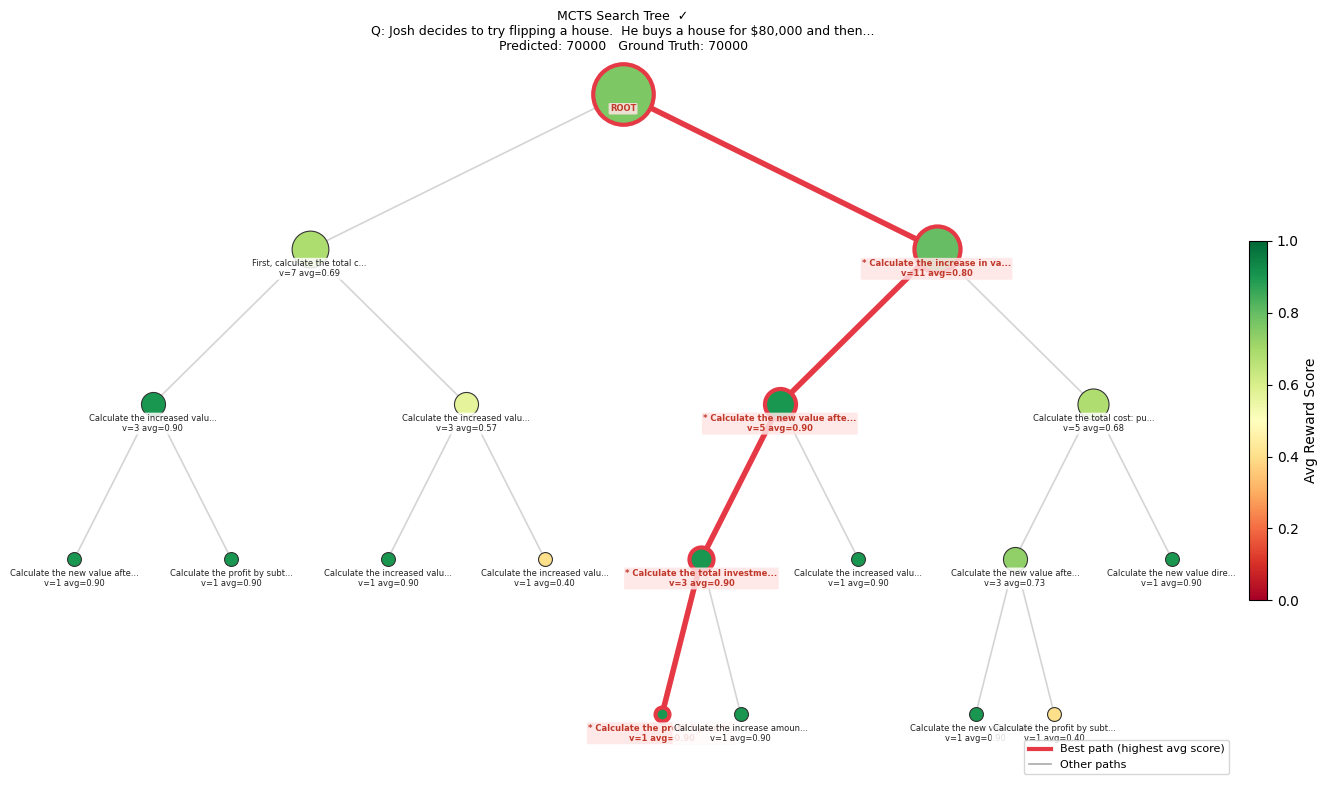

Q1 — Pred: 70000  GT: 70000  ✓


In [98]:
#visualize tree
r0 = results_mcts[5]  #choose which Q&A you wait to visualize


fig, ax = plt.subplots(figsize=(15, 8))
draw_mcts_tree(r0['root'], r0['question'], r0['true_answer'], r0['final'], ax=ax)
plt.tight_layout()
plt.savefig('mcts_tree_q1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Q1 — Pred: {r0['final']}  GT: {r0['true_answer']}  {'✓' if r0['correct'] else '✗'}")

if you want to have a deeper tree and more reasoning directions, then increase k and the iteration

let's look at the best reasoning path

In [99]:
def print_best_path_reasoning(result):
    """show full reasoning text"""
    root = result['root']

    def find_best_path(node):
        if not node.children:
            return [node]
        best = max(node.children, key=lambda n: n.avg_value())
        return [node] + find_best_path(best)

    path = find_best_path(root)

    print('=' * 70)
    print('BEST PATH — Step-by-step reasoning')
    print('=' * 70)
    for i, node in enumerate(path):
        prefix = 'ROOT' if i == 0 else f'Step {i} *'
        print(f'\n[{prefix}]  visits={node.visits}  avg={node.avg_value():.2f}')
        print(f'  {node.step_text}')
        if node.rollout_scores:
            print(f'  Rollout scores: {[round(s,2) for s in node.rollout_scores]}')

    print('\n' + '-' * 70)
    print(f'Final Answer: {result.get("final")}')
    print('-' * 70)
print(r0['question'])
print_best_path_reasoning(r0)

Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
BEST PATH — Step-by-step reasoning

[ROOT]  visits=19  avg=0.76
  [root]
  Rollout scores: [0.9]

[Step 1 *]  visits=11  avg=0.80
  Calculate the increase in value: 150% of the original purchase price is $80,000 × 1.5.
  Rollout scores: [0.9]

[Step 2 *]  visits=5  avg=0.90
  Calculate the new value after the increase: original price plus the increase, so $80,000 + ($80,000 × 1.5).
  Rollout scores: [0.9]

[Step 3 *]  visits=3  avg=0.90
  Calculate the total investment by adding the purchase price and repair cost: $80,000 + $50,000 = $130,000.
  Rollout scores: [0.9]

[Step 4 *]  visits=1  avg=0.90
  Calculate the profit by subtracting the total investment from the new value: ($80,000 + $120,000) - $130,000.
  Rollout scores: [0.9]

----------------------------------------------------------------------
Fina

compare with CoT reasoning

In [100]:
result_cot_compare  = cot(r0['question'], total_token_budget=1000, verbose=True)
print(result_cot_compare)

  ---Reasoning-----
  │ Let’s break it down step by step.  
  │ 
  │ 1. **Initial cost of the house**: $80,000.  
  │ 2. **Cost of repairs**: $50,000.  
  │ 3. **Total investment** = $80,000 + $50,000 = $130,000.  
  │ 
  │ 4. **Increase in value**: The repairs increased the value of the house by **150%** of what?  
  │    The wording says “This increased the value of the house by 150%” — usually in such problems, “this” refers to the repairs, meaning the $50,000 in repairs increased the value by 150% of the repair cost.  
  │ 
  │    So, increase in value = 150% of $50,000 = \( 1.5 \times 50,000 = 75,000 \).  
  │ 
  │ 5. **Original value before repairs** = $80,000 (purchase price).  
  │    New value after repairs = original value + increase = \( 80,000 + 75,000 = 155,000 \).  
  │ 
  │ 6. **Profit** = Selling price − Total investment  
  │    = \( 155,000 - 130,000 = 25,000 \).  
  │ 
  │ Final Answer: 25000
  --------
{'method': 'CoT', 'final': '25000', 'text': 'Let’s break it down

### Evaluator Score Distribution

/tmp/ipykernel_11322/1959994690.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(scores_by_q, patch_artist=True, labels=labels_by_q)


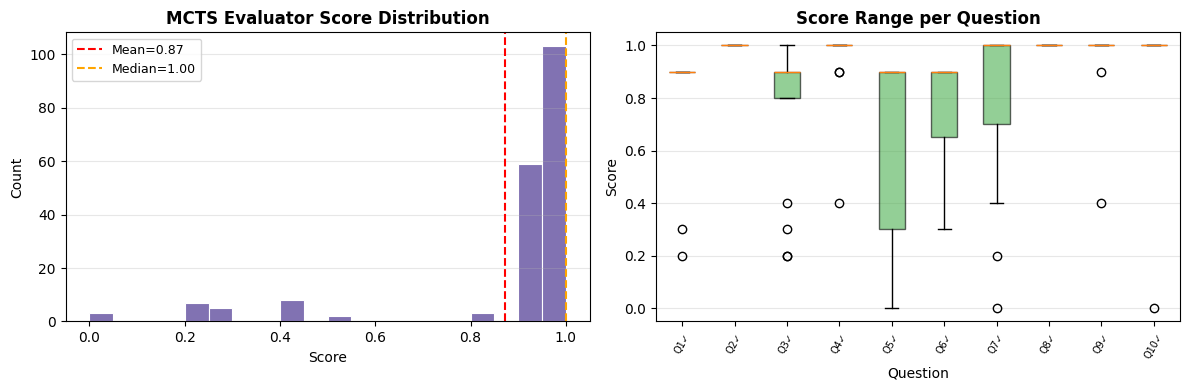

Score stats: mean=0.872  std=0.239  min=0.000  max=1.000


In [101]:
all_scores = []
for r in results_mcts:
    root = r.get('root')
    if root is None: continue
    def collect(node):
        all_scores.extend(node.rollout_scores)
        for c in node.children: collect(c)
    collect(root)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(all_scores, bins=20, range=(0,1), color='#8172B2', edgecolor='white', linewidth=0.8)
ax.axvline(np.mean(all_scores), color='red',    linestyle='--',
            label=f'Mean={np.mean(all_scores):.2f}')
ax.axvline(np.median(all_scores), color='orange', linestyle='--',
            label=f'Median={np.median(all_scores):.2f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count')
ax.set_title('MCTS Evaluator Score Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
scores_by_q, labels_by_q = [], []
for qi, r in enumerate(results_mcts):
    root = r.get('root')
    if root is None: continue
    qs = []
    def collect_q(node):
        qs.extend(node.rollout_scores)
        for c in node.children: collect_q(c)
    collect_q(root)
    if qs:
        scores_by_q.append(qs)
        labels_by_q.append(f"Q{qi+1}{'✓' if r['correct'] else '✗'}")

bp = ax.boxplot(scores_by_q, patch_artist=True, labels=labels_by_q)
for patch, r in zip(bp['boxes'], results_mcts):
    patch.set_facecolor('#4CAF50' if r['correct'] else '#F44336')
    patch.set_alpha(0.6)
ax.set_xlabel('Question'); ax.set_ylabel('Score')
ax.set_title('Score Range per Question', fontweight='bold')
ax.tick_params(axis='x', rotation=60, labelsize=7)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mcts_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Score stats: mean={np.mean(all_scores):.3f}  std={np.std(all_scores):.3f}  '
      f'min={np.min(all_scores):.3f}  max={np.max(all_scores):.3f}')

## Fair Comparison: Token-Normalized Results

**Critical:** MCTS uses many more LLM calls than CoT. Raw accuracy comparison alone is misleading.

We measure four metrics:
1. **Accuracy** — % questions answered correctly
2. **Avg tokens** — total API tokens per question
3. **Avg latency** — wall-clock seconds per question
4. **Tokens per correct** — efficiency: tokens spent to get one right answer

In [102]:
def aggregate(results, label):
    n       = len(results)
    correct = sum(r['correct'] for r in results)
    tokens  = [r.get('tokens_used', 0) for r in results]
    lats    = [r.get('latency', 0) for r in results]
    return {
        'method':        label,
        'n':             n,
        'accuracy':      correct / n,
        'correct':       correct,
        'avg_tokens':    float(np.mean(tokens)),
        'avg_latency':   float(np.mean(lats)),
        'tok_per_correct': float(np.mean(tokens)) / max(correct / n, 1e-6),
    }

stats = [
    aggregate(results_cot,  'CoT'),
    aggregate(results_sc,   'Self-Consistency'),
    aggregate(results_bon,  'Best-of-N'),
    aggregate(results_mcts, 'MCTS'),
]
df_stats = pd.DataFrame(stats)

print('\n------Comparison TableTable---------------------------------------')
print(df_stats[['method','accuracy','correct','avg_tokens','avg_latency','tok_per_correct']]
      .rename(columns={'accuracy':'acc','avg_tokens':'tok','avg_latency':'lat(s)',
                       'tok_per_correct':'tok/correct'})
      .to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print('--------------------------------------------------------------------')



------Comparison TableTable---------------------------------------
          method  acc  correct     tok  lat(s)  tok/correct
             CoT 0.90        9  284.90    5.39       316.56
Self-Consistency 0.90        9  856.80   16.48       952.00
       Best-of-N 0.70        7 1808.50   20.46      2583.57
            MCTS 1.00       10 7470.50  164.42      7470.50
--------------------------------------------------------------------


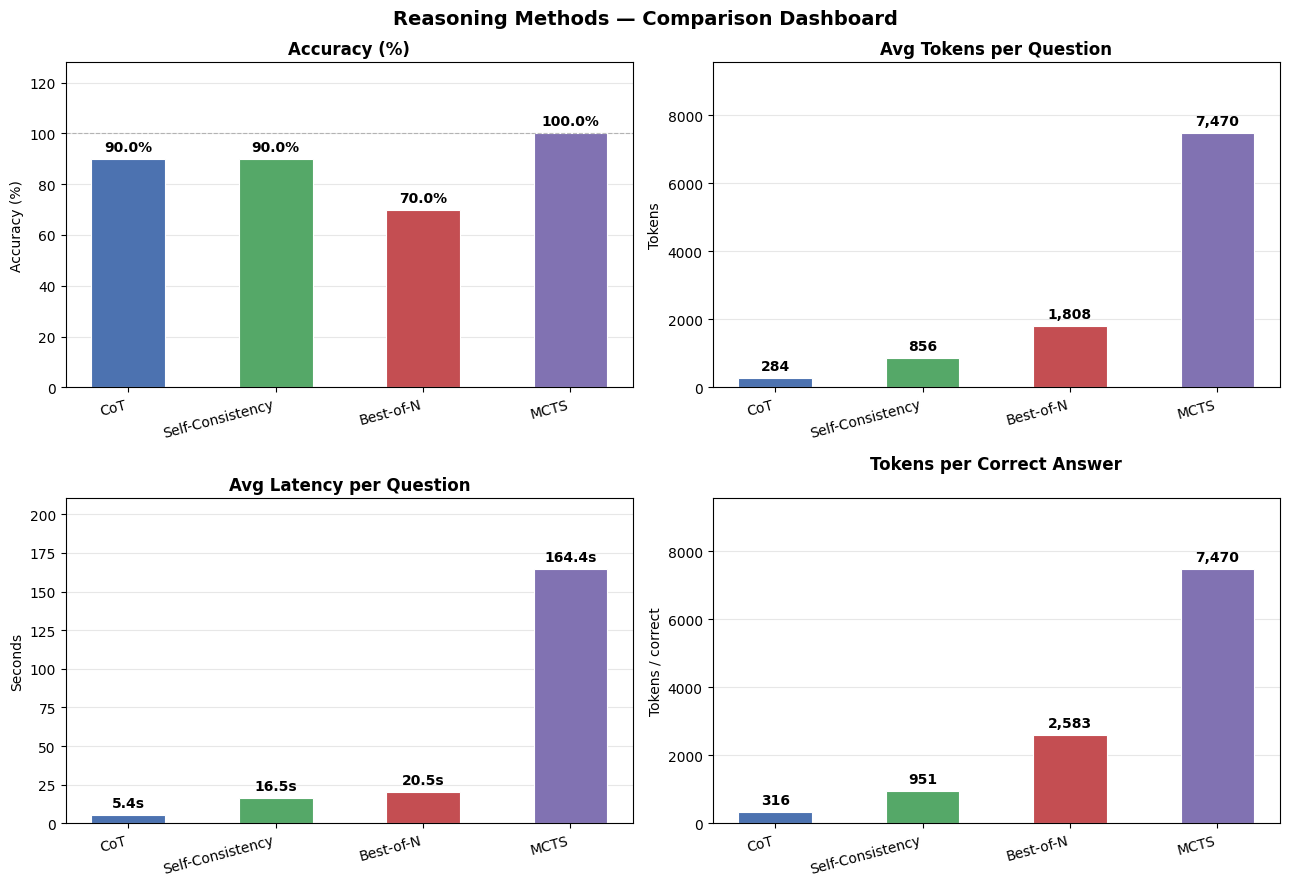

In [103]:
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
methods = df_stats['method'].tolist()
x = np.arange(len(methods))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Reasoning Methods — Comparison Dashboard', fontsize=14, fontweight='bold')

def bar_chart(ax, values, title, ylabel, fmt_fn=lambda v: f'{v:.0f}'):
    bars = ax.bar(x, values, color=COLORS, width=0.5, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ymax = max(values) if max(values) > 0 else 1
    ax.set_ylim(0, ymax * 1.28)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ymax * 0.02,
                fmt_fn(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

bar_chart(axes[0,0], (df_stats['accuracy']*100).tolist(),
          'Accuracy (%)', 'Accuracy (%)', fmt_fn=lambda v: f'{v:.1f}%')
axes[0,0].axhline(df_stats['accuracy'].max()*100, color='gray',
                   linestyle='--', linewidth=0.8, alpha=0.5)

bar_chart(axes[0,1], df_stats['avg_tokens'].tolist(),
          'Avg Tokens per Question', 'Tokens', fmt_fn=lambda v: f'{int(v):,}')

bar_chart(axes[1,0], df_stats['avg_latency'].tolist(),
          'Avg Latency per Question', 'Seconds', fmt_fn=lambda v: f'{v:.1f}s')

bar_chart(axes[1,1], df_stats['tok_per_correct'].tolist(),
          'Tokens per Correct Answer\n',
          'Tokens / correct', fmt_fn=lambda v: f'{int(v):,}')

plt.tight_layout()
plt.savefig('comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### Per-Question Correctness Heatmap


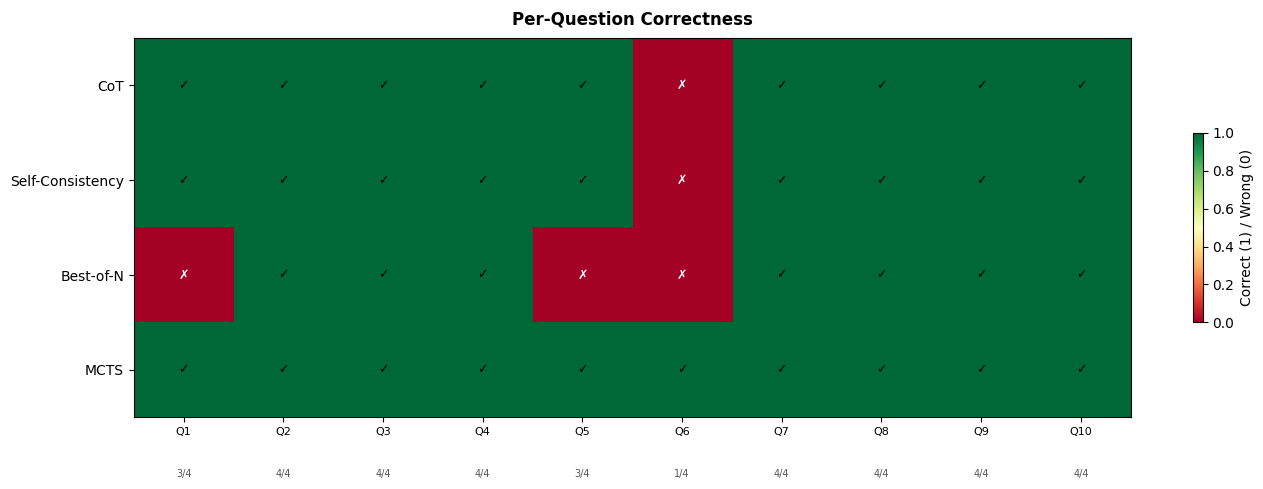

In [104]:
fig, ax = plt.subplots(figsize=(14, max(5, len(df_test) * 0.42)))

method_results = {
    'CoT':              [r['correct'] for r in results_cot],
    'Self-Consistency': [r['correct'] for r in results_sc],
    'Best-of-N':        [r['correct'] for r in results_bon],
    'MCTS':             [r['correct'] for r in results_mcts],
}
matrix = np.array(list(method_results.values()), dtype=float)

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(df_test)))
ax.set_xticklabels([f'Q{i+1}' for i in range(len(df_test))], fontsize=8)
ax.set_yticks(range(4))
ax.set_yticklabels(list(method_results.keys()))
ax.set_title('Per-Question Correctness', fontweight='bold', pad=10)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, '✓' if matrix[i, j] else '✗',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if matrix[i, j] == 0 else 'black')

plt.colorbar(im, ax=ax, label='Correct (1) / Wrong (0)', shrink=0.5)

# Show per-column agreement
for j, s in enumerate(matrix.sum(axis=0)):
    ax.text(j, 4.15, f'{int(s)}/4', ha='center', va='bottom', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('correctness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Accuracy vs Token Cost — The Tradeoff


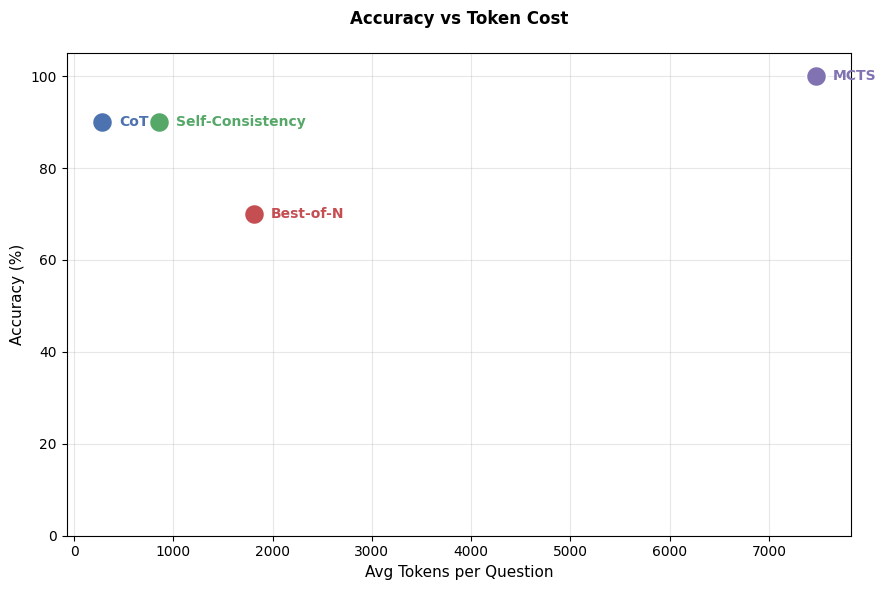

In [105]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, row in df_stats.iterrows():
    ax.scatter(row['avg_tokens'], row['accuracy']*100,
               color=COLORS[i], s=220, zorder=5, edgecolor='white', linewidth=1.5)
    ax.annotate(row['method'],
                xy=(row['avg_tokens'], row['accuracy']*100),
                xytext=(12, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLORS[i], va='center')

ax.set_xlabel('Avg Tokens per Question', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Token Cost\n', fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Insights

### Method Comparison

| Method | Strengths | Weaknesses |
|---|---|---|
| **CoT** | Fast, cheap, often sufficient | One bad step → wrong chain, no backtracking |
| **Self-Consistency** | Robust to random errors | Systematic errors not fixed by voting |
| **Best-of-N** | Handles diverse answer space | LLM self-scoring has bias |
| **MCTS** | Strategic search, reuses partial reasoning | Higher latency and token cost |

### When Does MCTS Help?
- **Multi-step problems with false starts** — can backtrack and explore alternative paths
- **Problems where first intuition is wrong** — exploration finds alternatives CoT misses
- **Larger iteration/compute budgets** — more search iterations → better coverage

### Fairness Note
Raw accuracy comparison is **misleading** without controlling for token budget. The **accuracy-vs-token-cost scatter** and **tokens-per-correct-answer** are the honest metrics.


### Important Distinction: System-Level vs. Model-Level Reasoning
It is crucial to understand that the methods demonstrated in this notebook (CoT, MCTS, Best-of-N) are forms of System-Level Scaffolding.

- What we did here: We took a standard, non-reasoning LLM and wrote external Python code to force it to generate steps, vote, or build a search tree. The "thinking" happens in the visible output tokens and is managed by our code.

- What this is NOT: This is not the same as native "Thinking Models" (e.g., OpenAI o1, DeepSeek-R1). Those models are trained using Reinforcement Learning (RL) to natively perform complex reasoning in a hidden latent space before outputting an answer. Their ability to backtrack, verify, and correct is baked into their neural network weights, not controlled by an external Python script.

- Takeaway: Wrapping a standard LLM in MCTS simulates the behavior of advanced reasoning models, allowing us to boost the performance of smaller/standard models, but at a high API token and latency cost.

## Conclusions on Reasoning Mechanisms

- ### The Trade-off between 'Reflex' and 'Reasoning'
  At their core, all large language models are predictive systems. By applying MCTS, we are shifting the model from a **"fast reflex"** state (System 1) to a **"slow thinking"** state (System 2). This does not alter the internal architecture of the model; rather, it fundamentally changes how we extract and leverage its computational power.

- ### The Evaluator (The Bottleneck)
  A significant hurdle in implementing this system is the capacity for self-assessment. In real-world production environments, maximum efficiency is typically achieved by using a specialized **Reward Model (RM)** or **Process Reward Model (PRM)**.

  In this notebook, we are pushing the model's limits by forcing it to grade its own work—a process that demands a level of logical rigor that models may not consistently achieve without the algorithmic constraints imposed by the search process.

- ### The Cost of Precision
  Forcing the model to "think" through multiple MCTS iterations effectively eliminates "hallucinated" or careless errors, but it comes at the price of significantly higher resource consumption. This reinforces a key insight:

> **AI intelligence is not solely determined by its parameters, but also by the protocol and procedural rigor we compel it to follow during inference.**